# Assumption on Linear Regression
- Liearity
- Normal of Residuals
- Homoscedasticity
- Number of Auto-Correlation
- Multicollinearity

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

### Linearity

In [20]:
# generating data
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8
z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.randn(100, 1)
df = pd.DataFrame()
df['x1'] = x.reshape(100)
df['x2'] = y.reshape(100)
df['y'] = z.reshape(100)

df.sample(5)

,x1,x2,y
51,-1.238062,-1.616258,5.423360
43,-1.397884,2.456652,10.194430
14,3.920707,-1.412292,20.199559
92,-0.917953,2.125504,8.005200
57,-0.186925,-1.633830,6.423267


Text(0.5, 1.0, 'X2 - Y')

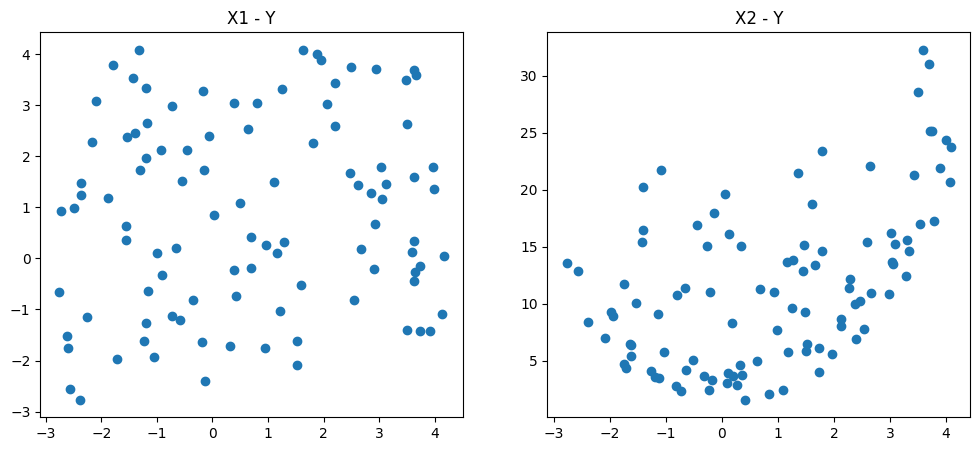

In [21]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12, 5))
# plot x1 - y
ax1.scatter(df['x1'], df['x2'])
ax1.set_title('X1 - Y')

# plot x2 - y
ax2.scatter(df['x2'], df['y'])
ax2.set_title('X2 - Y')

In [22]:
# fit a Linear Regression model
x = df[['x1', 'x2']]
y = df['y']
model = LinearRegression()
model.fit(x, y)
y_pred = model.predict(x)

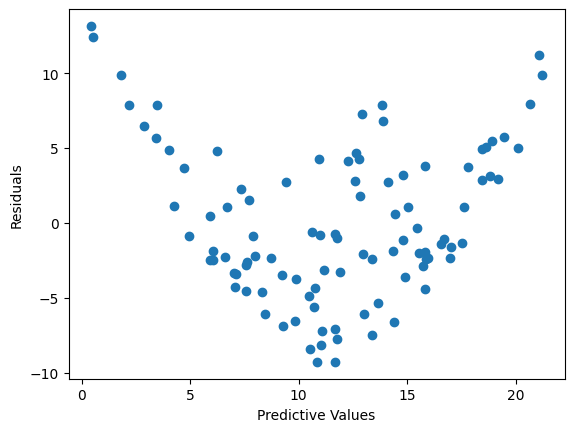

In [23]:
residuals = y - y_pred
# residuals - predictive values plot
plt.scatter(y_pred, residuals)
plt.xlabel('Predictive Values')
plt.ylabel('Residuals')
plt.show()

In [24]:
# fit a Polynomial model
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [27]:
# polynomial model
poly_features = PolynomialFeatures(degree=2)
x_train_poly = poly_features.fit_transform(x_train)
x_test_poly = poly_features.transform(x_test)

poly_model = LinearRegression()
poly_model.fit(x_train_poly, y_train)
y_pred_poly = poly_model.predict(x_test_poly)

# linear mmodel
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)
y_pred_linear = linear_model.predict(x_test)

In [28]:
print("r2 score of linear model : ", r2_score(y_pred_linear, y_test))
print("r2 score of polynomial model : ", r2_score(y_pred_poly, y_test))

r2 score of linear model :  0.04117534664481881
r2 score of polynomial model :  0.9761353098318215
